# Análise e visualização — Protocolo ENMC ($K_{ref}$ guiando R-NSGA-II e PI-NSGA-II)

Lê os CSVs gerados pelo experimento (`Pesquisa_ENMC_KneeRef.ipynb`) e produz **todas as
tabelas e figuras do artigo**. Não re-executa nenhum algoritmo.

## Escopo (decisão de orientação)

As métricas de cobertura (HV e IGD restritos a uma ROI de raio fixo) ficam para a versão
estendida. O termo *ROI* permanece no artigo em sentido conceitual (vizinhança do *knee
point*), sem delimitação métrica.

A análise publicada é composta por: **(1)** distâncias *knee* → ideal global (mínimo por
objetivo sobre a união das 63 frentes), **(2)** comparação pareada 1×1 contra o NSGA-II
individual, **(3)** concentração da população em torno de $K_{ref}$ — todas com média,
desvio-padrão amostral, mín/máx, boxplots e Wilcoxon pareado.

## 1. Configuração e estilo de publicação

In [1]:
#!pip install -q pymoo seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path
from IPython.display import display

# ---------------- estilo de publicação ----------------
sns.set_theme(context="paper", style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.format": "pdf",
    "font.family": "serif", "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
# Paleta ÚNICA do artigo. NÃO redefinir COR em nenhuma outra célula:
#   cinza = NSGA-II (sem preferência) | azul = R-NSGA-II | vermelho = PI-NSGA-II
COR = {"NSGA-II": "#9E9E9E", "R-NSGA-II": "#0072B2", "PI-NSGA-II": "#A81313"}
C_REF   = "#BDBDBD"   # P_ref ao fundo
C_KNEE  = "#000000"   # knees por execução
C_KREF  = "#2A2A2A"   # K_ref
C_IDEAL = "#E0A300"   # ponto ideal
PASTA_FIG = Path("figuras"); PASTA_FIG.mkdir(exist_ok=True)

def salvar(fig, nome):
    p = PASTA_FIG / f"{nome}.pdf"; fig.savefig(p); print("salvo:", p)

# ---------------- arquivos do experimento ----------------
SUFIXO  = "pop100_gen300_runs21"          # <-- ajuste se mudou os parâmetros
CSV_F1  = f"enmc_fase1_nsga2_{SUFIXO}.csv"
CSV_F2  = f"enmc_fase2_rnsga2_{SUFIXO}.csv"
CSV_F3  = f"enmc_fase3_pinsga2_{SUFIXO}.csv"
CSV_REF = f"enmc_referencias_{SUFIXO}.csv"

## 2. Funções de análise

In [3]:
# Funções de análise (as mesmas do experimento — reconstroem tudo do CSV)

def filtrar_nao_dominados(F):
    F = np.asarray(F, float)
    keep = np.ones(len(F), bool)
    for i in range(len(F)):
        if keep[i]:
            dom = np.all(F <= F[i], axis=1) & np.any(F < F[i], axis=1)
            if dom.any(): keep[i] = False
    return F[keep]

def normalizar(F, F_min, F_max):
    return (np.atleast_2d(F) - F_min) / (F_max - F_min + 1e-12)

def knee_point(F):
    F = np.atleast_2d(F)
    n_pts, n_obj = F.shape
    if n_pts <= 2: return F[0]
    Fmin, Fmax = F.min(0), F.max(0)
    Fn = (F - Fmin) / (Fmax - Fmin + 1e-12)
    extremos = Fn[np.argmin(Fn, axis=0)]
    try:
        a, *_  = np.linalg.lstsq(extremos, np.ones(n_obj), rcond=None)
        norm_a = np.linalg.norm(a)
        if not np.isfinite(norm_a) or norm_a < 1e-12:
            raise np.linalg.LinAlgError
        knee_idx = int(np.argmax(np.abs(Fn @ a - 1.0) / norm_a))
    except np.linalg.LinAlgError:
        knee_idx = int(np.argmin(np.linalg.norm(Fn - 0.5, axis=1)))
    return F[knee_idx]

print("Funções de análise definidas")

Funções de análise definidas


## 3. Carregar CSVs e reconstruir o experimento

In [4]:
# ================= Carregar CSVs e reconstruir o experimento =================
def _frentes_por_run(df, nome, alg):
    sub = df[(df["problema"] == nome) & (df["algoritmo"] == alg)]
    if sub.empty: return None
    d = 3 if sub["f3"].notna().any() else 2
    cols = ["f1", "f2", "f3"][:d]
    return [g[cols].to_numpy(float) for _, g in sub.groupby("run")]

df1, df2, df3 = pd.read_csv(CSV_F1), pd.read_csv(CSV_F2), pd.read_csv(CSV_F3)
refs = pd.read_csv(CSV_REF)
PROBLEMAS = list(df1["problema"].unique())

exp = {}
for nome in PROBLEMAS:
    f1 = _frentes_por_run(df1, nome, "NSGA-II")
    f2 = _frentes_por_run(df2, nome, "R-NSGA-II")
    f3 = _frentes_por_run(df3, nome, "PI-NSGA-II")
    P_ref = filtrar_nao_dominados(np.vstack(f1))
    r = refs[refs["problema"] == nome].set_index("tipo")
    d = f1[0].shape[1]
    cols = ["f1", "f2", "f3"][:d]
    K_ref = r.loc["K_ref", cols].to_numpy(float)

    # ideal e nadir GLOBAIS: união das 63 frentes (protocolo) — a régua fixa da análise
    uniao   = np.vstack(f1 + f2 + f3)
    ideal_g = uniao.min(axis=0)
    nadir_g = uniao.max(axis=0)

    exp[nome] = {"dim": d, "NSGA-II": f1, "R-NSGA-II": f2, "PI-NSGA-II": f3,
                 "P_ref": P_ref, "K_ref": K_ref, "ideal_g": ideal_g, "nadir_g": nadir_g,
                 "knees": {"R-NSGA-II":  [knee_point(F) for F in f2],
                           "PI-NSGA-II": [knee_point(F) for F in f3]}}
    print(f"{nome:11s}: {d} objs | runs N/R/PI = {len(f1)}/{len(f2)}/{len(f3)} | "
          f"P_ref {len(P_ref)} pts | K_ref {np.round(K_ref, 4)}")

Truss2D    : 2 objs | runs N/R/PI = 21/21/21 | P_ref 616 pts | K_ref [1.50000000e-02 2.67284292e+04]
WeldedBeam : 2 objs | runs N/R/PI = 21/21/21 | P_ref 735 pts | K_ref [7.4371e+00 2.4000e-03]
Carside    : 3 objs | runs N/R/PI = 21/21/21 | P_ref 1077 pts | K_ref [27.9428  3.8557 11.5271]


## 4. Distâncias knee → ideal + Wilcoxon pareado *(tabela de distâncias do artigo)*

In [5]:
# ========== Tabelas: 21 distâncias knee -> ideal + Wilcoxon pareado ==========
# CORRIGIDO: DP amostral (ddof=1) — antes usava np.std (ddof=0, populacional),
# inconsistente com a tabela de concentração, que usa pandas (ddof=1).
# CORRIGIDO: removido o truncamento silencioso min(len(dR), len(dPI)) — se faltar
# execução, o pareamento quebra e o assert avisa.
def dist_ideal(nome, k):
    m = exp[nome]
    return float(np.linalg.norm(normalizar(k, m["ideal_g"], m["nadir_g"]).ravel()))

linhas, dists = [], {}
for nome in PROBLEMAS:
    m = exp[nome]
    d_ref = dist_ideal(nome, m["K_ref"])
    dR  = np.array([dist_ideal(nome, k) for k in m["knees"]["R-NSGA-II"]])
    dPI = np.array([dist_ideal(nome, k) for k in m["knees"]["PI-NSGA-II"]])
    dists[nome] = {"R-NSGA-II": dR, "PI-NSGA-II": dPI, "d_ref": d_ref}
    assert len(dR) == len(dPI), f"{nome}: nº de execuções difere — pareamento inválido"
    try:    p_w = wilcoxon(dR, dPI)[1]
    except Exception: p_w = float("nan")
    for alg, d in [("R-NSGA-II", dR), ("PI-NSGA-II", dPI)]:
        linhas.append({"Problema": nome, "Algoritmo": alg, "n": len(d),
                       "Média": f"{d.mean():.4f}", "DP": f"{d.std(ddof=1):.4f}",
                       "Mín": f"{d.min():.4f}", "Máx": f"{d.max():.4f}",
                       "d(K_ref, I)": f"{d_ref:.4f}",
                       "p Wilcoxon (pareado)": f"{p_w:.4f}"})

tab = pd.DataFrame(linhas)
display(tab)
tab.to_csv(PASTA_FIG / "tabela_distancias_enmc.csv", index=False)
tab.to_latex(PASTA_FIG / "tabela_distancias_enmc.tex", index=False, escape=False)
print("Exportado: tabela_distancias_enmc.csv / .tex")

,Problema,Algoritmo,n,Média,DP,Mín,Máx,"d(K_ref, I)",p Wilcoxon (pareado)
0,Truss2D,R-NSGA-II,21,0.3061,0.0247,0.2873,0.3655,0.2866,0.0090
1,Truss2D,PI-NSGA-II,21,0.2905,0.0103,0.2866,0.3340,0.2866,0.0090
2,WeldedBeam,R-NSGA-II,21,0.1585,0.0089,0.1544,0.1923,0.1545,0.0002
3,WeldedBeam,PI-NSGA-II,21,0.1855,0.0588,0.1544,0.4269,0.1545,0.0002
4,Carside,R-NSGA-II,21,0.8356,0.0036,0.8321,0.8459,0.8408,0.0001
5,Carside,PI-NSGA-II,21,0.9698,0.1284,0.8038,1.1263,0.8408,0.0001


Exportado: tabela_distancias_enmc.csv / .tex


## 5. Comparação pareada 1×1 contra o NSGA-II individual *(tabela pareada do artigo)*

In [6]:
# ========== Comparação pareada 1x1: NSGA-II individual x algoritmos guiados ==========
# Fecha a assimetria metodológica: até aqui, UMA execução guiada era comparada ao
# K_ref, que é o knee de P_ref (agregado de 21 execuções do NSGA-II). Aqui a
# comparação é execução a execução, pareada pela MESMA semente.
knees_nsga = {nome: [knee_point(filtrar_nao_dominados(F)) for F in exp[nome]["NSGA-II"]]
              for nome in PROBLEMAS}

linhas_1x1 = []
for nome in PROBLEMAS:
    m = exp[nome]
    d_n = np.array([dist_ideal(nome, k) for k in knees_nsga[nome]])
    for alg in ["R-NSGA-II", "PI-NSGA-II"]:
        d_a = np.array([dist_ideal(nome, k) for k in m["knees"][alg]])
        assert len(d_n) == len(d_a), f"{nome}/{alg}: nº de execuções difere — pareamento inválido"
        try:    pv = wilcoxon(d_n, d_a)[1]
        except Exception: pv = float("nan")
        linhas_1x1.append({
            "Problema": nome, "Comparação": f"NSGA-II x {alg}",
            "NSGA-II (méd±DP)": f"{d_n.mean():.4f}±{d_n.std(ddof=1):.4f}",
            "Guiado (méd±DP)":  f"{d_a.mean():.4f}±{d_a.std(ddof=1):.4f}",
            "Vitórias do guiado": f"{int(np.sum(d_a < d_n))}/{len(d_a)}",
            "p (Wilcoxon pareado)": f"{pv:.4f}",
        })
tab_1x1 = pd.DataFrame(linhas_1x1)
display(tab_1x1)
tab_1x1.to_latex(PASTA_FIG / "tabela_pareado_1x1.tex", index=False, escape=False)
print("Exportado: tabela_pareado_1x1.tex")

,Problema,Comparação,NSGA-II (méd±DP),Guiado (méd±DP),Vitórias do guiado,p (Wilcoxon pareado)
0,Truss2D,NSGA-II x R-NSGA-II,0.2894±0.0019,0.3061±0.0247,8/21,0.0142
1,Truss2D,NSGA-II x PI-NSGA-II,0.2894±0.0019,0.2905±0.0103,16/21,0.1032
2,WeldedBeam,NSGA-II x R-NSGA-II,0.1670±0.0116,0.1585±0.0089,19/21,0.0029
3,WeldedBeam,NSGA-II x PI-NSGA-II,0.1670±0.0116,0.1855±0.0588,10/21,0.2572
4,Carside,NSGA-II x R-NSGA-II,0.9068±0.1132,0.8356±0.0036,15/21,0.0239
5,Carside,NSGA-II x PI-NSGA-II,0.9068±0.1132,0.9698±0.1284,8/21,0.1193


Exportado: tabela_pareado_1x1.tex


## 6. Concentração em torno de $K_{ref}$ *(tabela do artigo + dados da Figura 3)*

,Problema,Algoritmo,Média,DP,Mín,Máx
0,Carside,NSGA-II,0.5373,0.0151,0.5049,0.5615
1,Carside,PI-NSGA-II,0.3701,0.0964,0.2037,0.5489
2,Carside,R-NSGA-II,0.0080,0.0005,0.0068,0.0088
3,Truss2D,NSGA-II,0.3766,0.0107,0.3561,0.3937
4,Truss2D,PI-NSGA-II,0.2681,0.1023,0.0440,0.4191
5,Truss2D,R-NSGA-II,0.0246,0.0041,0.0172,0.0321
6,WeldedBeam,NSGA-II,0.2517,0.0232,0.2209,0.3011
7,WeldedBeam,PI-NSGA-II,0.1272,0.0911,0.0062,0.3538
8,WeldedBeam,R-NSGA-II,0.0090,0.0015,0.0062,0.0111


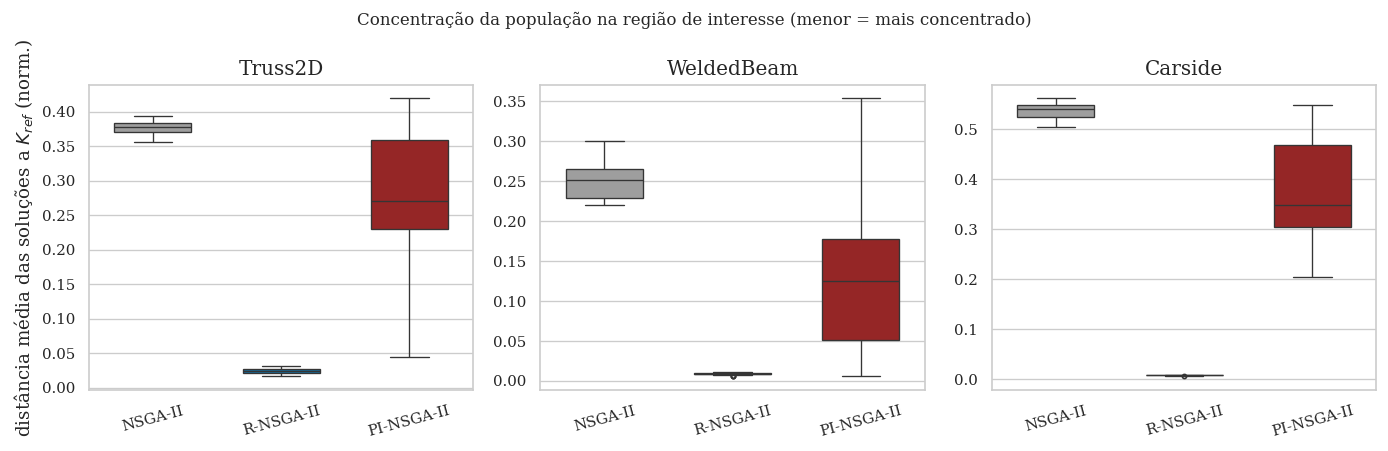

In [7]:
# ========== Concentração em torno de K_ref (refinamento do orientador) ==========
# Distância média das soluções de cada frente a K_ref: separa POSIÇÃO do knee de
# CONCENTRAÇÃO da população na região de interesse.
reg = []
for nome in PROBLEMAS:
    m = exp[nome]
    Kr = normalizar(m["K_ref"], m["ideal_g"], m["nadir_g"]).ravel()
    for alg in ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]:
        for run, F in enumerate(m[alg]):
            Fn = normalizar(F, m["ideal_g"], m["nadir_g"])
            reg.append({"Problema": nome, "Algoritmo": alg, "run": run,
                        "conc": float(np.linalg.norm(Fn - Kr, axis=1).mean())})
conc = pd.DataFrame(reg)

tabc = (conc.groupby(["Problema", "Algoritmo"])["conc"]
        .agg(Média="mean", DP="std", Mín="min", Máx="max").round(4).reset_index())
display(tabc)
tabc.to_latex(PASTA_FIG / "tabela_concentracao_enmc.tex", index=False, escape=False)

fig, axes = plt.subplots(1, len(PROBLEMAS), figsize=(3.9*len(PROBLEMAS), 3.8))
axes = np.atleast_1d(axes)
ordem = ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]
for ax, nome in zip(axes, PROBLEMAS):
    sub = conc[conc["Problema"] == nome]
    sns.boxplot(data=sub, x="Algoritmo", y="conc", hue="Algoritmo", order=ordem,
                palette=COR, ax=ax, width=.6, linewidth=.8, fliersize=2.5, legend=False)
    ax.set_title(nome); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
axes[0].set_ylabel(r"distância média das soluções a $K_{ref}$ (norm.)")
for ax in axes[1:]: ax.set_ylabel("")
fig.suptitle("Concentração da população na região de interesse (menor = mais concentrado)",
             fontsize=10)
fig.tight_layout(); plt.show()   # visualização rápida — a figura do artigo é salva na Seção 9

## 7. Knee da frente combinada (agregado × agregado — checagem de sanidade)

Para o NSGA-II, o knee combinado **é** o $K_{ref}$: a linha dele deve reproduzir exatamente a base $d(K_{ref}, I)$.

In [8]:
# Distância do knee da FRENTE COMBINADA de cada algoritmo ao ideal
# (nota do coorientador: "distância do ideal, frentes combinadas também")
linhas_ag = []
for nome in PROBLEMAS:
    m = exp[nome]
    for alg in ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]:
        P_comb = filtrar_nao_dominados(np.vstack(m[alg]))   # 21 frentes -> não dominados
        K_comb = knee_point(P_comb)
        linhas_ag.append({"Problema": nome, "Algoritmo": alg,
                          "d(K_combinado, I)": round(dist_ideal(nome, K_comb), 4)})
tab_ag = pd.DataFrame(linhas_ag)
display(tab_ag)
tab_ag.to_latex(PASTA_FIG / "tabela_knee_combinado_enmc.tex", index=False, escape=False)

,Problema,Algoritmo,"d(K_combinado, I)"
0,Truss2D,NSGA-II,0.2866
1,Truss2D,R-NSGA-II,0.3334
2,Truss2D,PI-NSGA-II,0.2869
3,WeldedBeam,NSGA-II,0.1545
4,WeldedBeam,R-NSGA-II,0.1698
5,WeldedBeam,PI-NSGA-II,0.1561
6,Carside,NSGA-II,0.8408
7,Carside,R-NSGA-II,0.8340
8,Carside,PI-NSGA-II,0.8420


## 8. Coletor: exporta todos os números para montar o LaTeX

In [9]:
# ========== COLETOR: exporta todos os números da análise em um .txt organizado ==========
# Roda depois de todas as células acima (usa exp, dists, dist_ideal, knees_nsga,
# conc, PROBLEMAS). Gera "resultados_para_prompt.txt" — é só abrir e colar no chat.
import io, numpy as np, pandas as pd
from scipy.stats import wilcoxon

ALGS3 = ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]
buf = io.StringIO()
def w(*a): print(*a, file=buf)

w("="*70)
w("RESULTADOS ENMC — DADOS PARA MONTAR A SEÇÃO DE RESULTADOS")
w("Protocolo: 21 execuções/algoritmo · sementes 42-62 · pop 100 · 300 gerações")
w("Ideal global = mínimo por objetivo sobre a união das 63 frentes (21×3).")
w("Distâncias em espaço normalizado (adimensional). DP amostral (ddof=1).")
w("="*70)

# ---------- 0. Referências por problema ----------
w("\n### 0. FRONTEIRA E KNEE DE REFERÊNCIA (por problema)")
for nome in PROBLEMAS:
    m = exp[nome]
    kref = np.array2string(m["K_ref"], precision=4, separator=", ")
    w(f"- {nome}: dim={m['dim']} | |P_ref|={len(m['P_ref'])} | "
      f"K_ref(bruto)={kref} | base d(K_ref,ideal)={dists[nome]['d_ref']:.4f}")

# ---------- 1. Distâncias knee->ideal (Tabela 3) ----------
w("\n### 1. DISTÂNCIA DO KNEE AO IDEAL — 21 execuções (Tabela de distâncias)")
w("problema | algoritmo | média | DP | mín | máx | base | p(R vs PI)")
for nome in PROBLEMAS:
    dR, dPI = dists[nome]["R-NSGA-II"], dists[nome]["PI-NSGA-II"]
    base = dists[nome]["d_ref"]
    try: pw = wilcoxon(dR, dPI)[1]
    except Exception: pw = float("nan")
    for alg, d in [("R-NSGA-II", dR), ("PI-NSGA-II", dPI)]:
        w(f"{nome} | {alg} | {d.mean():.4f} | {d.std(ddof=1):.4f} | "
          f"{d.min():.4f} | {d.max():.4f} | {base:.4f} | {pw:.4f}")

# ---------- 2. Pareada 1x1 vs NSGA-II individual (Tabela 4) ----------
w("\n### 2. COMPARAÇÃO PAREADA 1x1 (guiado vs NSGA-II individual, por semente)")
w("problema | comparação | NSGA-II méd±DP | guiado méd±DP | vitórias guiado | p")
for nome in PROBLEMAS:
    d_n = np.array([dist_ideal(nome, k) for k in knees_nsga[nome]])
    for alg in ["R-NSGA-II", "PI-NSGA-II"]:
        d_a = np.array([dist_ideal(nome, k) for k in exp[nome]["knees"][alg]])
        try: pv = wilcoxon(d_n, d_a)[1]
        except Exception: pv = float("nan")
        w(f"{nome} | NSGA-II x {alg} | {d_n.mean():.4f}±{d_n.std(ddof=1):.4f} | "
          f"{d_a.mean():.4f}±{d_a.std(ddof=1):.4f} | "
          f"{int(np.sum(d_a < d_n))}/{len(d_a)} | {pv:.4f}")

# ---------- 3. Concentração a K_ref (Tabela de concentração) ----------
w("\n### 3. CONCENTRAÇÃO — distância média das soluções a K_ref (21 execuções)")
w("problema | algoritmo | média | DP | mín | máx")
tc = (conc.groupby(["Problema","Algoritmo"])["conc"]
      .agg(m="mean", s="std", mn="min", mx="max").reset_index())
for nome in PROBLEMAS:
    for alg in ALGS3:
        r = tc[(tc["Problema"]==nome) & (tc["Algoritmo"]==alg)].iloc[0]
        w(f"{nome} | {alg} | {r['m']:.4f} | {r['s']:.4f} | {r['mn']:.4f} | {r['mx']:.4f}")

# Wilcoxon da concentração (R vs PI e R vs NSGA), pareado por run
w("\n### 3b. CONCENTRAÇÃO — Wilcoxon pareado")
w("problema | par | p")
for nome in PROBLEMAS:
    piv = (conc[conc["Problema"]==nome]
           .pivot(index="run", columns="Algoritmo", values="conc"))
    for a,b in [("R-NSGA-II","PI-NSGA-II"), ("R-NSGA-II","NSGA-II")]:
        try: pv = wilcoxon(piv[a], piv[b])[1]
        except Exception: pv = float("nan")
        w(f"{nome} | {a} vs {b} | {pv:.4f}")

# ---------- 4. Knee da frente combinada (agregado x agregado) ----------
w("\n### 4. KNEE DA FRENTE COMBINADA — distância ao ideal (1 valor por algoritmo)")
w("problema | algoritmo | d(K_combinado, ideal)")
for nome in PROBLEMAS:
    m = exp[nome]
    for alg in ALGS3:
        Kc = knee_point(filtrar_nao_dominados(np.vstack(m[alg])))
        w(f"{nome} | {alg} | {dist_ideal(nome, Kc):.4f}")

# ---------- 5. Extras úteis para o texto ----------
w("\n### 5. NÚMEROS DE APOIO PARA A DISCUSSÃO")
for nome in PROBLEMAS:
    dR, dPI = dists[nome]["R-NSGA-II"], dists[nome]["PI-NSGA-II"]
    base = dists[nome]["d_ref"]
    d_n = np.array([dist_ideal(nome, k) for k in knees_nsga[nome]])
    w(f"- {nome}: melhor média = "
      f"{'R-NSGA-II' if dR.mean()<dPI.mean() else 'PI-NSGA-II'} | "
      f"R min={dR.min():.4f} PI min={dPI.min():.4f} base={base:.4f} | "
      f"NSGA-II individual médio={d_n.mean():.4f}")

texto = buf.getvalue()
with open("resultados_para_prompt.txt", "w", encoding="utf-8") as f:
    f.write(texto)
print(texto)
print("\n>>> Arquivo salvo: resultados_para_prompt.txt")


RESULTADOS ENMC — DADOS PARA MONTAR A SEÇÃO DE RESULTADOS
Protocolo: 21 execuções/algoritmo · sementes 42-62 · pop 100 · 300 gerações
Ideal global = mínimo por objetivo sobre a união das 63 frentes (21×3).
Distâncias em espaço normalizado (adimensional). DP amostral (ddof=1).

### 0. FRONTEIRA E KNEE DE REFERÊNCIA (por problema)
- Truss2D: dim=2 | |P_ref|=616 | K_ref(bruto)=[1.4978e-02, 2.6728e+04] | base d(K_ref,ideal)=0.2866
- WeldedBeam: dim=2 | |P_ref|=735 | K_ref(bruto)=[7.4371e+00, 2.4211e-03] | base d(K_ref,ideal)=0.1545
- Carside: dim=3 | |P_ref|=1077 | K_ref(bruto)=[27.9428,  3.8557, 11.5271] | base d(K_ref,ideal)=0.8408

### 1. DISTÂNCIA DO KNEE AO IDEAL — 21 execuções (Tabela de distâncias)
problema | algoritmo | média | DP | mín | máx | base | p(R vs PI)
Truss2D | R-NSGA-II | 0.3061 | 0.0247 | 0.2873 | 0.3655 | 0.2866 | 0.0090
Truss2D | PI-NSGA-II | 0.2905 | 0.0103 | 0.2866 | 0.3340 | 0.2866 | 0.0090
WeldedBeam | R-NSGA-II | 0.1585 | 0.0089 | 0.1544 | 0.1923 | 0.1545 | 0.00

## 9. Figuras finais do artigo — painel unificado (a)–(g) e Figura 3 *(pedido do orientador)*

Substitui as antigas Figuras 2, 3 e 4 (frentes Welded Beam, frentes Carside e
boxplot de distâncias) por **uma única figura de página inteira**, com rótulos
de subfigura (a)–(g) referenciáveis no texto.

Layout:
- linha 1: frentes do **Welded Beam** — R-NSGA-II (a) e PI-NSGA-II (b)
- linha 2: frentes do **Carside** — R-NSGA-II (c) e PI-NSGA-II (d)
- linha 3: **boxplots** das distâncias — Truss2D (e), Welded Beam (f), Carside (g)

Demais decisões mantidas: paleta única `COR`, sem suptitle, knees com borda
branca, vírgula decimal, sem rotação de rótulos.

In [10]:
# ========== Setup das figuras finais ==========
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec

# vírgula decimal nos eixos (artigo em português)
fmt_virgula = FuncFormatter(lambda x, pos: f"{x:g}".replace(".", ","))

def salvar_pdf(fig, nome):
    """Salva em PDF vetorial pronto para o Overleaf e fecha a figura."""
    caminho = PASTA_FIG / f"{nome}.pdf"
    fig.savefig(
        caminho,
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )
    print("salvo:", caminho)
    plt.show()
    plt.close(fig)

def _marcadores(ax, knees_n, Kr, tresD=False):
    """Knees (21), K_ref e ideal com contraste sobre qualquer nuvem."""
    if tresD:
        ax.scatter(knees_n[:, 0], knees_n[:, 1], knees_n[:, 2], marker="D", s=30,
                   c=C_KNEE, edgecolors="white", linewidths=0.7, zorder=5,
                   label="knees (21)", depthshade=False)
        ax.scatter([Kr[0]], [Kr[1]], [Kr[2]], marker="X", s=150, c=C_KREF,
                   edgecolors="white", linewidths=1.0, zorder=6,
                   label="$K_{ref}$", depthshade=False)
        ax.scatter([0], [0], [0], marker="*", s=190, c=C_IDEAL,
                   edgecolors="black", linewidths=0.5, zorder=6,
                   label="ideal", depthshade=False)
    else:
        ax.scatter(knees_n[:, 0], knees_n[:, 1], marker="D", s=30,
                   c=C_KNEE, edgecolors="white", linewidths=0.7, zorder=5,
                   label="knees (21)")
        ax.scatter([Kr[0]], [Kr[1]], marker="X", s=150, c=C_KREF,
                   edgecolors="white", linewidths=1.0, zorder=6, label="$K_{ref}$")
        ax.scatter([0], [0], marker="*", s=190, c=C_IDEAL,
                   edgecolors="black", linewidths=0.5, zorder=6, label="ideal")

def _rotulo(ax, letra, tresD=False):
    """Rótulo (a), (b), ... no canto superior esquerdo do painel."""
    if tresD:
        ax.text2D(0.02, 0.96, f"({letra})", transform=ax.transAxes,
                  fontsize=11, fontweight="bold", va="top")
    else:
        ax.text(0.02, 0.97, f"({letra})", transform=ax.transAxes,
                fontsize=11, fontweight="bold", va="top")

print("setup ok")

setup ok


salvo: figuras\painel_resultados_enmc.pdf


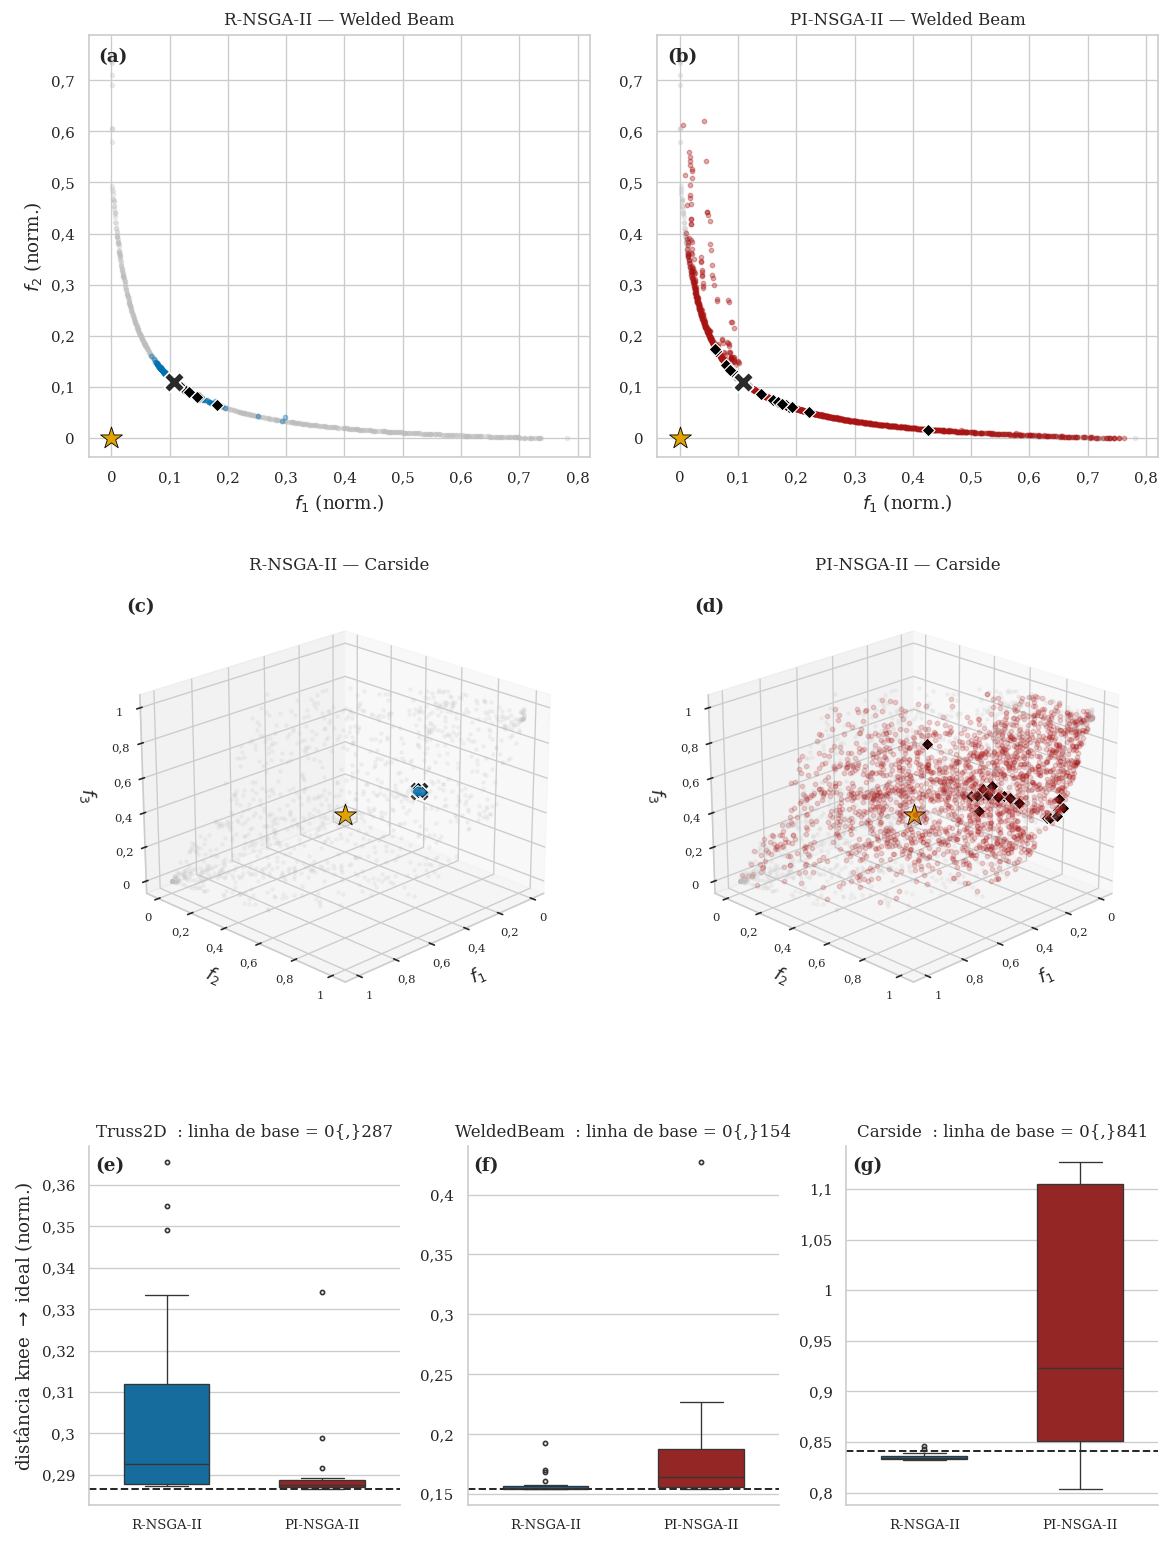

In [11]:
# ==============================================================
# FIGURA UNIFICADA — frentes (Welded Beam e Carside) + boxplots
# Ocupa uma página inteira. Substitui as antigas Figs. 2, 3 e 4.
# Legenda ÚNICA no topo: os itens (P_ref, soluções, knees, K_ref, ideal)
# são os mesmos nos quatro painéis de frentes — repeti-los 4x só ocupa espaço
# e colide com os rótulos (c)/(d) no 3D.
# ==============================================================
PROB_FRENTE_2D = "WeldedBeam"     # ajuste se a chave do seu CSV for outra
PROB_FRENTE_3D = "Carside"

fig = plt.figure(figsize=(11.5, 14.5))
# 6 colunas: linhas 1-2 usam 2 painéis (3 cols cada); linha 3 usa 3 painéis (2 cols cada)
gs = GridSpec(3, 6, figure=fig, hspace=0.30, wspace=0.55,
              height_ratios=[1.0, 1.05, 0.85], top=0.955)   # top: espaço p/ legenda

letras = iter("abcdefg")

# ---------- LINHA 1: frentes 2D (Welded Beam) ----------
m = exp[PROB_FRENTE_2D]
Pn = normalizar(m["P_ref"], m["ideal_g"], m["nadir_g"])
Kr = normalizar(m["K_ref"], m["ideal_g"], m["nadir_g"]).ravel()
for j, alg in enumerate(["R-NSGA-II", "PI-NSGA-II"]):
    ax = fig.add_subplot(gs[0, 3*j:3*(j+1)])
    ax.scatter(Pn[:, 0], Pn[:, 1], s=6, alpha=.25, c=C_REF,
               label="$P^{ref}$ (NSGA-II)", zorder=1)
    Fn_all = normalizar(np.vstack(m[alg]), m["ideal_g"], m["nadir_g"])
    # rótulo genérico: o algoritmo de cada painel já está no título
    ax.scatter(Fn_all[:, 0], Fn_all[:, 1], s=7, alpha=.35, c=COR[alg],
               label="soluções do algoritmo", zorder=2)
    kn = normalizar(np.vstack(m["knees"][alg]), m["ideal_g"], m["nadir_g"])
    _marcadores(ax, kn, Kr)
    _rotulo(ax, next(letras))
    ax.set_title(f"{alg} — Welded Beam", fontsize=10)
    ax.set_xlabel("$f_1$ (norm.)")
    if j == 0:
        ax.set_ylabel("$f_2$ (norm.)")
    ax.xaxis.set_major_formatter(fmt_virgula)
    ax.yaxis.set_major_formatter(fmt_virgula)
    if j == 0:                       # guarda os handles para a legenda única
        h_leg, l_leg = ax.get_legend_handles_labels()

# ---------- LINHA 2: frentes 3D (Carside) ----------
m = exp[PROB_FRENTE_3D]
Pn = normalizar(m["P_ref"], m["ideal_g"], m["nadir_g"])
Kr = normalizar(m["K_ref"], m["ideal_g"], m["nadir_g"]).ravel()
for j, alg in enumerate(["R-NSGA-II", "PI-NSGA-II"]):
    ax = fig.add_subplot(gs[1, 3*j:3*(j+1)], projection="3d")
    ax.scatter(Pn[:, 0], Pn[:, 1], Pn[:, 2], s=4, alpha=.12, c=C_REF,
               label="$P^{ref}$ (NSGA-II)", depthshade=False)
    Fn_all = normalizar(np.vstack(m[alg]), m["ideal_g"], m["nadir_g"])
    ax.scatter(Fn_all[:, 0], Fn_all[:, 1], Fn_all[:, 2], s=7, alpha=.18,
               c=COR[alg], label="soluções do algoritmo", depthshade=False)
    kn = normalizar(np.vstack(m["knees"][alg]), m["ideal_g"], m["nadir_g"])
    _marcadores(ax, kn, Kr, tresD=True)
    _rotulo(ax, next(letras), tresD=True)
    ax.set_title(f"{alg} — Carside", fontsize=10)
    ax.set_xlabel("$f_1$", labelpad=-2)
    ax.set_ylabel("$f_2$", labelpad=-2)
    ax.set_zlabel("$f_3$", labelpad=-2)
    ax.tick_params(labelsize=7, pad=-1)
    ax.xaxis.set_major_formatter(fmt_virgula)
    ax.yaxis.set_major_formatter(fmt_virgula)
    ax.zaxis.set_major_formatter(fmt_virgula)
    ax.view_init(elev=22, azim=45)
    # sem ax.legend() — legenda única no topo da figura

# ---------- LINHA 3: boxplots das distâncias ----------
reg = []
for nome in PROBLEMAS:
    for alg in ["R-NSGA-II", "PI-NSGA-II"]:
        for v in dists[nome][alg]:
            reg.append({"Problema": nome, "Algoritmo": alg, "dist": v})
long_d = pd.DataFrame(reg)

for j, nome in enumerate(PROBLEMAS):
    ax = fig.add_subplot(gs[2, 2*j:2*(j+1)])
    sub = long_d[long_d["Problema"] == nome]
    sns.boxplot(data=sub, x="Algoritmo", y="dist", hue="Algoritmo",
                order=["R-NSGA-II", "PI-NSGA-II"], palette=COR,
                ax=ax, width=.55, linewidth=.8, fliersize=2.5, legend=False)
    d_ref = dists[nome]["d_ref"]
    val = f"{d_ref:.3f}".replace(".", "{,}")
    # o VALOR vai para o título; a legenda fica genérica e unificada no topo
    ax.axhline(d_ref, ls="--", lw=1.2, color=C_KREF,
               label="linha de base $d(K_{ref}, z^{ideal})$")
    _rotulo(ax, next(letras))
    ax.set_title(f"{nome}  : linha de base = {val}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("distância knee $\\rightarrow$ ideal (norm.)" if j == 0 else "")
    ax.yaxis.set_major_formatter(fmt_virgula)
    ax.tick_params(axis="x", labelsize=8)
    sns.despine(ax=ax)
    if j == 0:                      # handles para a legenda única dos boxplots
        h_box, l_box = ax.get_legend_handles_labels()

# ---------- Legenda única dos boxplots (e)-(g) ----------
#fig.legend(h_box, l_box, loc="upper center", bbox_to_anchor=(0.5, 0.315),
           #ncol=1, fontsize=9, frameon=True, framealpha=.95)
# ==============================================================
# Salvamento em PDF vetorial para uso no Overleaf
# ==============================================================
salvar_pdf(fig, "painel_resultados_enmc")

salvo: figuras\concentracao_kref_enmc.pdf


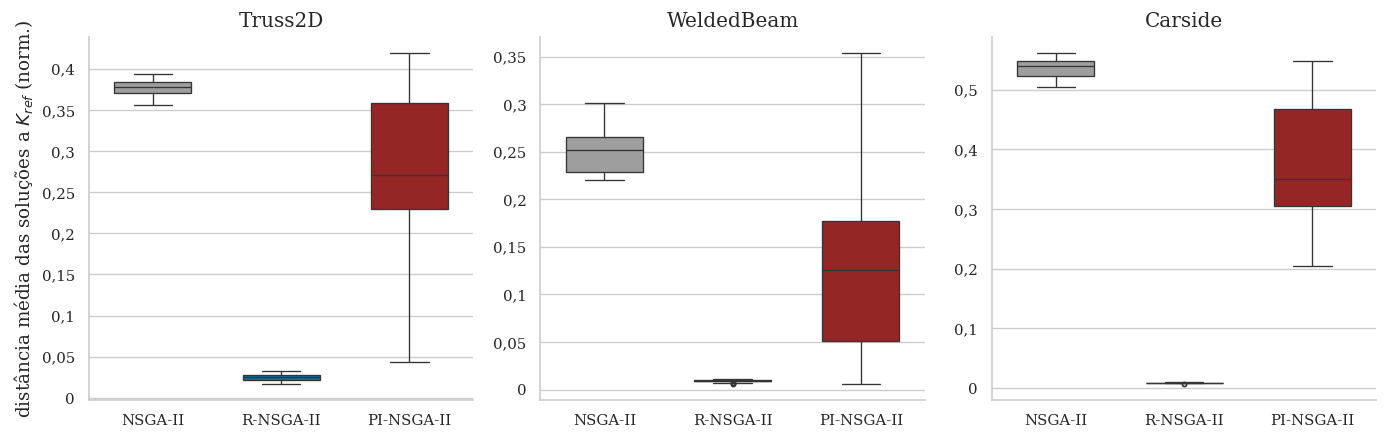

In [13]:
# ========== Figura 3 do artigo: boxplot de concentração ==========
# Salvaguarda: reafirma a paleta completa (única figura que plota os três algoritmos).
COR = {"NSGA-II": "#9E9E9E", "R-NSGA-II": "#0072B2", "PI-NSGA-II": "#A81313"}

ordem = ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]
fig, axes = plt.subplots(1, len(PROBLEMAS), figsize=(3.9*len(PROBLEMAS), 3.8))
axes = np.atleast_1d(axes)
for ax, nome in zip(axes, PROBLEMAS):
    sub = conc[conc["Problema"] == nome]
    sns.boxplot(data=sub, x="Algoritmo", y="conc", hue="Algoritmo", order=ordem,
                palette=COR, ax=ax, width=.6, linewidth=.8, fliersize=2.5,
                legend=False)
    ax.set_title(nome)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(fmt_virgula)
axes[0].set_ylabel("distância média das soluções a $K_{ref}$ (norm.)")
for ax in axes[1:]:
    ax.set_ylabel("")
sns.despine(fig)
fig.tight_layout()

# ==============================================================
# Salvamento em PDF vetorial para uso no Overleaf
# ==============================================================
salvar_pdf(fig, "concentracao_kref_enmc")